# 05 — Tag transactions

Tag each sales row with is_promo (promo_cal match), is_markdown (price < threshold × SKU median), is_stockout_week (inv=0 that week OR shipped < customer typical weekly).

**Upstream:** sales_with_brand.parquet, promo_cal.parquet, inv_weekly.parquet

**Output:** sales_tagged.parquet

**Promotes to:** `src/tagging.py` once verified.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

# Sales LOCNCODE -> DC string (matches inv_weekly.DC from step 04)
DC_MAP = {'1': 'SF', '2': 'NJ', '3': 'LA', 1: 'SF', 2: 'NJ', 3: 'LA'}

# Tunable thresholds
MARKDOWN_FACTOR = 0.70   # Unit_Price_adj < 0.70 * SKU median -> is_markdown


## 2. Load upstream

In [2]:
sales = pd.read_parquet(ART / 'sales_with_brand.parquet')
promo_cal = pd.read_parquet(ART / 'promo_cal.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')

# promo_cal.promo_ym was stringified on save; round-trip back to Period[M].
promo_cal['promo_ym'] = pd.PeriodIndex(promo_cal['promo_ym'], freq='M')

print(f'sales      : {sales.shape}   cols={list(sales.columns)[:8]}...')
print(f'promo_cal  : {promo_cal.shape}')
print(f'inv_weekly : {inv_weekly.shape}  confidence={inv_weekly["confidence"].value_counts().to_dict()}')


sales      : (236818, 24)   cols=['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE']...
promo_cal  : (1391, 3)
inv_weekly : (37887, 5)  confidence={'high': 33043, 'low': 4844}


## 3. Do the work

In [3]:
# ---- Normalize sales keys ---------------------------------------------------
sales = sales.copy()
sales['DOCDATE'] = pd.to_datetime(sales['DOCDATE'])
sales['sale_ym'] = sales['DOCDATE'].dt.to_period('M')
sales['DC'] = sales['LOCNCODE'].map(DC_MAP)
sales['week_start'] = sales['DOCDATE'].dt.to_period('W-SUN').dt.start_time

# ---- Flag 1: is_promo ------------------------------------------------------
# Exact (CUSTNMBR, brand, YYYY-MM) match against promo_cal. Sell-in window
# (sale_ym in [promo_ym-2, promo_ym]) is a refinement for later.
promo_keys = promo_cal.assign(is_promo=True)
sales = sales.merge(
    promo_keys,
    left_on=['CUSTNMBR', 'brand', 'sale_ym'],
    right_on=['CUSTNMBR', 'brand', 'promo_ym'],
    how='left',
)
sales['is_promo'] = sales['is_promo'].fillna(False)
sales = sales.drop(columns=['promo_ym'])

# ---- Flag 2: is_markdown ---------------------------------------------------
# Compute SKU median Unit_Price_adj from non-promo, positive-price rows only
# (so a SKU that's frequently on promo doesn't anchor its own "normal" price low).
base = sales[(~sales['is_promo']) & (sales['Unit_Price_adj'] > 0)]
sku_median_price = base.groupby('ITEMNMBR')['Unit_Price_adj'].median()
sales['sku_median_price'] = sales['ITEMNMBR'].map(sku_median_price)
sales['markdown_threshold'] = sales['sku_median_price'] * MARKDOWN_FACTOR
sales['is_markdown'] = (
    (sales['Unit_Price_adj'] > 0)
    & (sales['Unit_Price_adj'] < sales['markdown_threshold'])
    & sales['sku_median_price'].notna()
)

# ---- Flag 3: is_stockout_week ----------------------------------------------
# Join sales to inv_weekly on (ITEMNMBR, DC, week_start). on_hand_est <= 0 at
# the START of the sales week means the shelf was empty going in. Only trust
# the flag when the (SKU, DC) series is high-confidence.
sales = sales.merge(
    inv_weekly.rename(columns={'on_hand_est': 'week_on_hand', 'confidence': 'inv_confidence'}),
    on=['ITEMNMBR', 'DC', 'week_start'],
    how='left',
)
sales['is_stockout_week'] = (
    (sales['week_on_hand'] <= 0)
    & (sales['inv_confidence'] == 'high')
)
# If no inv row (non-physical DC like E1/W/ZD, or SKU not in snapshot), flag null
# so downstream can decide to drop or keep.
sales['is_stockout_week'] = sales['is_stockout_week'].where(
    sales['week_on_hand'].notna(), other=pd.NA,
)

# ---- Clean-demand flag -----------------------------------------------------
# Row counts as "clean" for demand modeling when none of the three flags fire.
# NA in is_stockout_week (missing inv) -> treat as not-stockout for clean flag
# but propagate the NA in inv_confidence so downstream sees the uncertainty.
sales['is_clean_demand'] = (
    (~sales['is_promo'])
    & (~sales['is_markdown'])
    & (sales['is_stockout_week'].fillna(False) == False)
)

# ---- Summary ---------------------------------------------------------------
n = len(sales)
print(f'total sales rows                : {n:,}')
print(f'is_promo         : {sales["is_promo"].sum():>8,} ({sales["is_promo"].mean()*100:5.1f}%)')
print(f'is_markdown      : {sales["is_markdown"].sum():>8,} ({sales["is_markdown"].mean()*100:5.1f}%)')
print(f'is_stockout_week : {(sales["is_stockout_week"]==True).sum():>8,} ({(sales["is_stockout_week"]==True).mean()*100:5.1f}%)')
print(f'  (stockout NA — no inv data)   : {sales["is_stockout_week"].isna().sum():,}')
print(f'is_clean_demand  : {sales["is_clean_demand"].sum():>8,} ({sales["is_clean_demand"].mean()*100:5.1f}%)')

print('\nflag overlap (is_promo × is_markdown):')
print(pd.crosstab(sales['is_promo'], sales['is_markdown']).to_string())


total sales rows                : 236,818
is_promo         :   29,421 ( 12.4%)
is_markdown      :    5,491 (  2.3%)
is_stockout_week :       98 (  0.0%)
  (stockout NA — no inv data)   : 30,563
is_clean_demand  :  202,476 ( 85.5%)

flag overlap (is_promo × is_markdown):
is_markdown   False  True 
is_promo                  
False        202548   4849
True          28779    642


## 4. Validate

row count preserved: 236,818
is_promo nulls         : 0
is_markdown nulls      : 0
is_stockout_week nulls : 30,563  (rows without inv_weekly coverage)

Markdown depth (price / sku_median):
count    5491.000000
mean        0.635169
std         0.071189
min         0.028003
25%         0.633162
50%         0.650138
75%         0.673030
max         0.699997


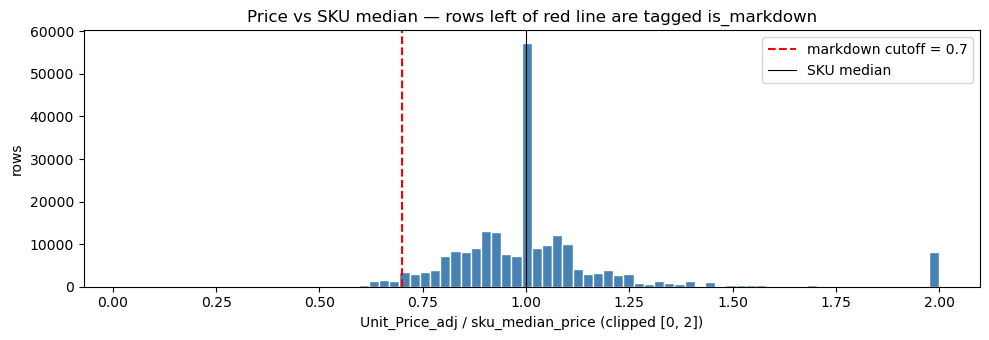


T-32206 (21,231 rows):
  is_promo         : 7,371  (34.7%)
  is_markdown      : 0  (0.0%)
  is_stockout_week : 98  (0.5%)
  is_clean_demand  : 13,788  (64.9%)
  sku_median_price : $3.36

is_promo rows by brand:


brand
tiger balm     22035
ginger chew     7300
am gsg            86


In [4]:
# ---- Check 1: shape + no row loss ------------------------------------------
sales_in = pd.read_parquet(ART / 'sales_with_brand.parquet')
assert len(sales) == len(sales_in), f'Row count changed! {len(sales_in)} -> {len(sales)}'
print(f'row count preserved: {len(sales):,}')

# ---- Check 2: null sanity on the 3 flags -----------------------------------
print(f'is_promo nulls         : {sales["is_promo"].isna().sum()}')
print(f'is_markdown nulls      : {sales["is_markdown"].isna().sum()}')
print(f'is_stockout_week nulls : {sales["is_stockout_week"].isna().sum():,}  (rows without inv_weekly coverage)')

# ---- Check 3: markdown threshold distribution ------------------------------
# How much below median are the markdown rows?
md = sales[sales['is_markdown'] & sales['sku_median_price'].notna()].copy()
md['price_ratio'] = md['Unit_Price_adj'] / md['sku_median_price']
print(f'\nMarkdown depth (price / sku_median):')
print(md['price_ratio'].describe().to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
# All positive-price rows with sku_median -> ratio distribution, highlight md cutoff
all_ratio = (sales.loc[sales['Unit_Price_adj'] > 0, 'Unit_Price_adj']
             / sales.loc[sales['Unit_Price_adj'] > 0, 'sku_median_price']).dropna()
ax.hist(all_ratio.clip(0, 2), bins=80, color='steelblue', edgecolor='white')
ax.axvline(MARKDOWN_FACTOR, color='red', linestyle='--',
           label=f'markdown cutoff = {MARKDOWN_FACTOR}')
ax.axvline(1.0, color='black', linestyle='-', lw=0.8, label='SKU median')
ax.set_xlabel('Unit_Price_adj / sku_median_price (clipped [0, 2])')
ax.set_ylabel('rows')
ax.set_title('Price vs SKU median — rows left of red line are tagged is_markdown')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 4: spot-check showcase SKU --------------------------------------
sku = 'T-32206'
sub = sales[sales['ITEMNMBR'] == sku]
print(f'\n{sku} ({len(sub):,} rows):')
print(f'  is_promo         : {sub["is_promo"].sum():,}  ({sub["is_promo"].mean()*100:.1f}%)')
print(f'  is_markdown      : {sub["is_markdown"].sum():,}  ({sub["is_markdown"].mean()*100:.1f}%)')
print(f'  is_stockout_week : {(sub["is_stockout_week"]==True).sum():,}  ({(sub["is_stockout_week"]==True).mean()*100:.1f}%)')
print(f'  is_clean_demand  : {sub["is_clean_demand"].sum():,}  ({sub["is_clean_demand"].mean()*100:.1f}%)')
print(f'  sku_median_price : ${sub["sku_median_price"].iloc[0]:.2f}')

# ---- Check 5: is_promo sanity — which brands light up? --------------------
print('\nis_promo rows by brand:')
print(sales[sales['is_promo']].groupby('brand').size().sort_values(ascending=False).to_string())


## 5. Save downstream artifact

In [5]:
# Drop intermediate helper cols so the output parquet is focused.
# Keep: original sales cols + the 4 flags + threshold/median for audit.
out_cols = list(sales.columns)
# Cast is_stockout_week object (bool / pd.NA) to nullable boolean for parquet.
sales['is_stockout_week'] = sales['is_stockout_week'].astype('boolean')

sales.to_parquet(ART / 'sales_tagged.parquet')
print(f'sales_tagged  {sales.shape}  -> sales_tagged.parquet')
print(f'columns: {list(sales.columns)}')


sales_tagged  (236818, 35)  -> sales_tagged.parquet
columns: ['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE', 'DOCDATE', 'ITEMNMBR', 'ITEMDESC', 'QUANTITY_adj', 'UOFM', 'QTYBSUOM', 'XTNDPRCE_adj', 'EXTDCOST_adj', 'Customer Type', 'Product Type', 'Source_File', 'Gross_Profit_adj', 'Margin_Pct_adj', 'UOM_Price', 'Unit_Price_adj', 'brand', 'sale_ym', 'DC', 'week_start', 'is_promo', 'sku_median_price', 'markdown_threshold', 'is_markdown', 'week_on_hand', 'inv_confidence', 'is_stockout_week', 'is_clean_demand']


## 6. Promote

Once validation above looks right, extract the core logic into `src/tagging.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.